XGBoost - CPCV and walk-forward validation:

1. First use CPCV to find optimal hyperparameters.
2. Then validate the model with walk-forward.

Cotributions:
1. Lpoez de Prado - Advances in ML for Finance
2. https://blog.quantinsti.com/cross-validation-embargo-purging-combinatorial/

In [1]:
# Import libraries:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import combinations
from collections import defaultdict

from xgboost import XGBClassifier
from sklearn.model_selection import BaseCrossValidator, ParameterGrid
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
import joblib

In [2]:
# Import data:
# run script from the data_input file
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("momentum_labeled.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','trend_bin']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df_features = pd.read_csv("final_features.csv", parse_dates=['Date'])
df_features = df_features.set_index('Date')


data = pd.concat([df_features,df_factor], axis=1, join='inner')
data = data.dropna()

print(data)

            Value_geommean_1m  Value_geommean_3m  Value_geommean_6m  \
Date                                                                  
2012-09-01               0.03           0.023322           0.011442   
2012-10-01               0.02           0.023322           0.014786   
2012-11-01               0.04           0.029968           0.016421   
2012-12-01               0.01           0.023258           0.023290   
2013-01-01               0.04           0.029902           0.026607   
...                       ...                ...                ...   
2023-02-01               0.05           0.031880           0.023753   
2023-03-01              -0.05          -0.014338           0.018462   
2023-04-01              -0.05          -0.017772           0.011486   
2023-05-01               0.04          -0.020900           0.005143   
2023-06-01              -0.08          -0.031317          -0.022864   

            SA_NB_Curvature  SA_NB_Level_QS  SA_NB_Level_TS  SA_NB_Slope_TS 

In [3]:
# Phase 1: Combinatorial CV for Model Development

# Configuration
# n_samples = 130
CV_SPLITS = 5 # each split is about 26 months/ not more than 5
CV_TEST_SPLITS = 1 # 26 months of testing
PURGE_GAP = 6  # drop 6 months of either side of test split (lose 24mnths to purging)
FINAL_TEST_POINTS = 36  # 3 years of unseen data

class CombinatorialPurgedCV(BaseCrossValidator):
    #Purged Combinatorial Cross-Validation (De Prado style)
    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, purge_gap=PURGE_GAP):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge_gap = purge_gap
    
    def split(self, X, y=None, groups=None): 
        n_samples = len(X)
        fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)
        
        # Create fold boundaries
        fold_boundaries = [(i * fold_size, (i + 1) * fold_size) for i in range(self.n_splits)]
        fold_boundaries[-1] = (fold_boundaries[-1][0], n_samples)  # extend last fold to end
        
        # Generate all possible test fold combinations
        test_fold_combinations = combinations(range(self.n_splits), self.n_test_splits)
        
        for test_fold_indices in test_fold_combinations:
            test_mask = np.zeros(n_samples, dtype=bool)
            
            # Collect test indices
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]
                test_mask[start:end] = True
            
            # Start with everything else as train
            train_mask = ~test_mask
            
            # Purge around EACH test fold
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]
                # purge before
                purge_start = max(0, start - self.purge_gap)
                purge_end = start
                train_mask[purge_start:purge_end] = False
                # purge after
                purge_start = end
                purge_end = min(n_samples, end + self.purge_gap)
                train_mask[purge_start:purge_end] = False
            
            yield indices[train_mask], indices[test_mask]
    
    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)


In [4]:

def tune_hyperparameters(X, y):
    cv = CombinatorialPurgedCV()
    # Define parameter grid to search
    # grid has 1262 parameter combinations
    # I still need to implement an early stop rpotocol
    param_grid = {
    'learning_rate': [0.01, 0.04, 0.2],              # Wider range
    'max_depth': [8, 16, 32],                        # Deeper trees 
    'subsample': [0.4, 0.7, 1.0],                    # More regularization
    'colsample_bytree': [0.4, 0.7, 1.0],
    #'n_parameters': [100, 500, 1000],  
    'base_score': [0.5] 
    }
    
    best_score = -np.inf
    best_params = None
    results = []
    #feature_importances = []  
    
    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")
    for params in ParameterGrid(param_grid):
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=1000,
            **params
        )
        
        fold_scores = []
        fold_importances = []  
        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            model.fit(X_train, y_train,verbose=False)
            score = accuracy_score(y_test, model.predict(X_test))
            fold_scores.append(score)
            fold_importances.append(model.feature_importances_)
        
        mean_score = np.mean(fold_scores)
        results.append((params, mean_score))

        avg_importance = np.mean(fold_importances, axis=0)
        #feature_importances.append((params, avg_importance))
        
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            print(f"New best params: {best_params} (accuracy: {best_score:.3f})")
    
    # Sort results by performance
    results.sort(key=lambda x: x[1], reverse=True)
    
    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")
    
    return best_params 


In [5]:
# Phase 2: Walk-Forward Validation for Final Evaluation
def walk_forward_validation(X, y, n_test, model_params):
    """
    if 'base_score' not in model_params:
        model_params['base_score'] = 0.5
    elif model_params['base_score'] <= 0 or model_params['base_score'] >= 1:
        model_params['base_score'] = 0.5
    """   
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=1000,
        **model_params
    )
    
    actuals, predictions, probabilities = [], [], []
    #wfv_importances = []
    
    print(f"\nRunning Walk-Forward Validation on {n_test} test samples...")
    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue
            
        X_train, X_test = X[:train_size], X[train_size:train_size+1]
        y_train, y_test = y[:train_size], y[train_size:train_size+1]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        probabilities.append(y_prob[0])
        #wfv_importances.append(model.feature_importances_)
    
    if not actuals:
        raise ValueError("No predictions were made during walk-forward validation")
    
    print("\n=== Final Evaluation Results ===")
    print("Classification Report:")
    print(classification_report(actuals, predictions))
    
    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label='Actual', marker='o')
    plt.plot(predictions, label='Predicted', marker='x')
    plt.plot(probabilities, label='Probability', linestyle='--', alpha=0.5)
    plt.title('Walk-Forward Validation Results')
    plt.legend()
    plt.show()
    
    return actuals, predictions, probabilities
   

=== PHASE 1: HYPERPARAMETER TUNING ===
Testing 81 parameter combinations...


New best params: {'base_score': 0.5, 'colsample_bytree': 0.4, 'learning_rate': 0.01, 'max_depth': 8, 'subsample': 0.4} (accuracy: 0.638)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.4, 'learning_rate': 0.01, 'max_depth': 8, 'subsample': 1.0} (accuracy: 0.669)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.7, 'learning_rate': 0.04, 'max_depth': 8, 'subsample': 0.7} (accuracy: 0.669)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 8, 'subsample': 1.0} (accuracy: 0.685)

=== Top 5 Parameter Combinations ===
Score: 0.685 | Params: {'base_score': 0.5, 'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 8, 'subsample': 1.0}
Score: 0.685 | Params: {'base_score': 0.5, 'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 16, 'subsample': 1.0}
Score: 0.685 | Params: {'base_score': 0.5, 'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 32, 'subsample': 1.0}
Score: 0.669 | Params: {'base_score': 0.5

100%|██████████| 36/36 [00:14<00:00,  2.47it/s]



=== Final Evaluation Results ===
Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.68      0.70        19
         1.0       0.67      0.71      0.69        17

    accuracy                           0.69        36
   macro avg       0.69      0.70      0.69        36
weighted avg       0.70      0.69      0.69        36



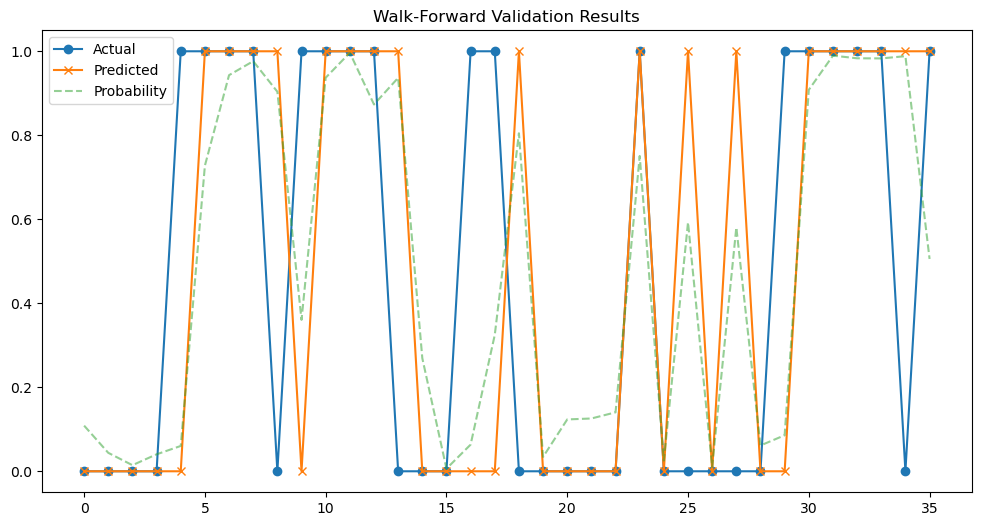

In [6]:
# Load data and execute
def main():
    # Load data
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist() 
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)
    
    # Phase 1: Hyperparameter tuning
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X, y)  
    
    # Phase 2: Final evaluation
    print("\n=== PHASE 2: FINAL EVALUATION ===")
    actuals, preds, probs = walk_forward_validation(X, y, FINAL_TEST_POINTS, best_params)
    
    return best_params, feature_names, X, y

if __name__ == "__main__":
    best_params, feature_names, X, y = main()


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)

def plot_wfv_results(actuals, predictions, probabilities):
    # --- ROC AUC ---
    auc = roc_auc_score(actuals, probabilities)
    avg_prec = average_precision_score(actuals, probabilities)
    
    print(f"ROC AUC: {auc:.3f}")
    print(f"Average Precision (PR AUC): {avg_prec:.3f}")
    
    # --- Timeline plot ---
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label='Actual', marker='o')
    plt.plot(predictions, label='Predicted', marker='x')
    plt.plot(probabilities, label='Probability', linestyle='--', alpha=0.5)
    plt.title('Walk-Forward Validation Results')
    plt.legend()
    plt.show()
    
    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(actuals, probabilities)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    
    # --- Precision-Recall Curve ---
    prec, rec, _ = precision_recall_curve(actuals, probabilities)
    plt.figure(figsize=(6, 6))
    plt.plot(rec, prec, label=f'PR Curve (AP = {avg_prec:.3f})', color='purple')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()
    
    # --- Confusion Matrix ---
    cm = confusion_matrix(actuals, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


In [8]:
# Run walk-forward
#actuals, predictions, probabilities = walk_forward_validation(X, y, n_test=50, model_params=best_params)

# Plot results separately
plot_wfv_results(actuals, predictions, probabilities)

NameError: name 'actuals' is not defined